In [1]:
import pandas as pd
import torch
import numpy as np
from cgmvae import*
from torch.nn import functional as F
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# load original input data
# actually we don't really need to do this unless we're interested in accuracy of reconstruction too, but we don't necessarily need to be 
# load latent variables 
latent_features_train = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
latent_features_train

,LV1,LV2,LV3,LV4,LV5,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,1.648254,1.558364,1.450668,1.713205,1.723632,DO-1D-3168,1D,DO-1D-3168,-0.820451
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722,DO-40-2083,40,DO-40-2083,0.780704
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421,DO-20-1186,20,DO-20-1186,0.452638
3,0.956853,1.063802,1.653756,1.514652,1.608262,DO-1D-3059,1D,DO-1D-3059,1.698389
4,1.407127,1.454008,1.323928,1.397264,1.267337,DO-40-2002,40,DO-40-2002,-0.582971
...,...,...,...,...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811,DO-1D-3185,1D,DO-1D-3185,-1.763434
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390,DO-2D-4058,2D,DO-2D-4058,0.951265
400,1.344620,1.542254,1.234269,1.474108,1.414498,DO-20-1053,20,DO-20-1053,-0.787807
401,0.919085,0.931402,1.518434,1.483853,1.381329,DO-20-1044,20,DO-20-1044,1.624125


In [3]:
data_with_cfc_labels = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/data_with_cfc_5bins.csv')
data_with_cfc_labels = data_with_cfc_labels[['MouseID', 'cfc_bin']]
data_with_cfc_labels

,MouseID,cfc_bin
0,DO-40-2162,0
1,DO-40-2179,1
2,DO-40-2181,1
3,DO-40-2187,2
4,DO-40-2099,1
...,...,...
499,DO-2D-4007,1
500,DO-1D-3030,1
501,DO-20-1021,0
502,DO-AL-0002,2


In [4]:
saved_model_path = '/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/saved_model_epoch5000.pth'

In [5]:
accelerator = True 

if accelerator:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
#vae = CGMVAE()
vae = torch.load(saved_model_path, map_location=device)
vae.to(device)
vae.eval()

CGMVAE(
  (label): Embedding(5, 1)
  (fc1): Linear(in_features=37, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=25, bias=True)
  (fc22): Linear(in_features=16, out_features=25, bias=True)
  (fc3): Linear(in_features=6, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=36, bias=True)
)

## Doing analysis with LV5 conditonal label 0

In [7]:
mouse_ids_0 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 0]['MouseID'].tolist()
latent_features_train_0 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_0)]
latent_features_train_0 = latent_features_train_0[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_0

,LV1,LV2,LV3,LV4,LV5
13,-0.893698,-0.720176,-0.866757,-0.823112,-1.094731
14,-1.622135,-1.356036,-1.420345,-1.495535,-1.267595
23,-0.957110,-0.818695,-0.948691,-0.993643,-0.997910
25,-1.577005,-1.315113,-1.407930,-1.409376,-1.314672
30,-1.276818,-1.093347,-1.127115,-1.167925,-0.975741
...,...,...,...,...,...
388,-1.436359,-1.235382,-1.249746,-1.297314,-0.932213
389,-1.141634,-0.943330,-0.982594,-1.051950,-0.920841
390,-1.327842,-1.144189,-1.166487,-1.188210,-1.019409
394,-1.513083,-1.272883,-1.293408,-1.326203,-1.131958


In [8]:
latent_features_train_mean_0 = latent_features_train_0.mean()
latent_features_train_mean_0

LV1   -1.348009
LV2   -1.133437
LV3   -1.187552
LV4   -1.229302
LV5   -1.090288
dtype: float64

In [9]:
min(latent_features_train_0['LV3']), max(latent_features_train_0['LV3'])

(-1.4525667845498529, -0.5845606076225852)

In [11]:
lv_traversal_values_0 = [-1.8, -1.4, -1, -0.6, 0.2]
latent_features_train_neg2_0 = latent_features_train_mean_0.copy()
latent_features_train_neg2_0.iloc[2] = lv_traversal_values_0[0]
latent_features_train_neg1_0 = latent_features_train_mean_0.copy()
latent_features_train_neg1_0.iloc[2] = lv_traversal_values_0[1]
latent_features_train_zero_0 = latent_features_train_mean_0.copy()
latent_features_train_zero_0.iloc[2] = lv_traversal_values_0[2]
latent_features_train_one_0 = latent_features_train_mean_0.copy()
latent_features_train_one_0.iloc[2] = lv_traversal_values_0[3]
latent_features_train_two_0 = latent_features_train_mean_0.copy()
latent_features_train_two_0.iloc[2] = lv_traversal_values_0[4]

In [12]:
stacked_data_input_0 = np.vstack((latent_features_train_neg2_0, latent_features_train_neg1_0, latent_features_train_zero_0, latent_features_train_one_0, latent_features_train_two_0))
stacked_data_input_0

array([[-1.34800858, -1.13343743, -1.8       , -1.22930228, -1.09028788],
       [-1.34800858, -1.13343743, -1.4       , -1.22930228, -1.09028788],
       [-1.34800858, -1.13343743, -1.        , -1.22930228, -1.09028788],
       [-1.34800858, -1.13343743, -0.6       , -1.22930228, -1.09028788],
       [-1.34800858, -1.13343743,  0.2       , -1.22930228, -1.09028788]])

In [14]:
z_traversal_0 = torch.tensor(stacked_data_input_0, dtype=torch.float32).to(device)
#y_labels = torch.tensor(np.ones(5), dtype=torch.long).to(device)
y_labels_0 = torch.tensor(np.zeros(5), dtype=torch.long).to(device)

## Prepare data for transversing LV5 with conditional label 1

In [15]:
mouse_ids_1 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 1]['MouseID'].tolist()
latent_features_train_1 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_1)]
latent_features_train_1 = latent_features_train_1[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_1

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
4,1.407127,1.454008,1.323928,1.397264,1.267337
15,1.219892,0.858839,0.811899,0.836143,0.712234
19,1.642225,1.663701,1.346894,1.761315,1.741227
21,1.510944,1.577664,1.146596,1.492334,1.343644
...,...,...,...,...,...
385,1.290042,1.164315,0.996189,1.291856,1.241618
387,1.512038,1.343424,1.239869,1.575708,1.555214
393,1.460973,1.360372,1.296377,1.578111,1.540010
400,1.344620,1.542254,1.234269,1.474108,1.414498


In [16]:
latent_features_train_mean_1 = latent_features_train_1.mean()
latent_features_train_mean_1

LV1    1.338759
LV2    1.337852
LV3    1.042993
LV4    1.238350
LV5    1.175304
dtype: float64

In [17]:
min(latent_features_train_1['LV3']), max(latent_features_train_1['LV3'])

(0.213536828261812, 1.585007314175427)

In [20]:
lv_traversal_values_1 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_1 = latent_features_train_mean_1.copy()
latent_features_train_neg2_1.iloc[2] = lv_traversal_values_1[0]
latent_features_train_neg1_1 = latent_features_train_mean_1.copy()
latent_features_train_neg1_1.iloc[2] = lv_traversal_values_1[1]
latent_features_train_zero_1 = latent_features_train_mean_1.copy()
latent_features_train_zero_1.iloc[2] = lv_traversal_values_1[2]
latent_features_train_one_1 = latent_features_train_mean_1.copy()
latent_features_train_one_1.iloc[2] = lv_traversal_values_1[3]
latent_features_train_two_1 = latent_features_train_mean_1.copy()
latent_features_train_two_1.iloc[2] = lv_traversal_values_1[4]

In [21]:
stacked_data_input_1 = np.vstack((latent_features_train_neg2_1, latent_features_train_neg1_1, latent_features_train_zero_1, latent_features_train_one_1, latent_features_train_two_1))
stacked_data_input_1

array([[1.33875905, 1.33785187, 0.        , 1.23834988, 1.17530418],
       [1.33875905, 1.33785187, 0.5       , 1.23834988, 1.17530418],
       [1.33875905, 1.33785187, 1.        , 1.23834988, 1.17530418],
       [1.33875905, 1.33785187, 1.5       , 1.23834988, 1.17530418],
       [1.33875905, 1.33785187, 2.        , 1.23834988, 1.17530418]])

In [22]:
z_traversal_1 = torch.tensor(stacked_data_input_1, dtype=torch.float32).to(device)
y_labels_1 = torch.tensor(np.ones(5), dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 2

In [23]:
mouse_ids_2 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 2]['MouseID'].tolist()
latent_features_train_2 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_2)]
latent_features_train_2 = latent_features_train_2[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_2

,LV1,LV2,LV3,LV4,LV5
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
5,0.035996,0.163485,0.447772,0.348364,0.387066
7,0.014778,-0.089215,0.067121,-0.068191,-0.177578
10,-0.055891,-0.020498,0.081582,-0.034955,-0.152137
11,0.142019,0.236467,0.418668,0.282368,0.217389
...,...,...,...,...,...
370,-0.149577,-0.281372,-0.351628,-0.525232,-0.632906
380,-0.082595,-0.111938,0.116845,-0.013294,0.003919
382,-0.117836,-0.044868,-0.031371,-0.131411,-0.181905
395,-0.126171,-0.197896,-0.105915,-0.251575,-0.388558


In [24]:
latent_features_train_mean_2 = latent_features_train_2.mean()
latent_features_train_mean_2

LV1   -0.110642
LV2   -0.064196
LV3    0.047799
LV4   -0.086370
LV5   -0.156310
dtype: float64

In [25]:
min(latent_features_train_2['LV3']), max(latent_features_train_2['LV3'])

(-0.4053634611909345, 0.8615674156322037)

In [26]:
lv_traversal_values_2 = [-0.9, -0.4, 0.1, 0.6, 1.1]
latent_features_train_neg2_2 = latent_features_train_mean_2.copy()
latent_features_train_neg2_2.iloc[2] = lv_traversal_values_2[0]
latent_features_train_neg1_2 = latent_features_train_mean_2.copy()
latent_features_train_neg1_2.iloc[2] = lv_traversal_values_2[1]
latent_features_train_zero_2 = latent_features_train_mean_2.copy()
latent_features_train_zero_2.iloc[2] = lv_traversal_values_2[2]
latent_features_train_one_2 = latent_features_train_mean_2.copy()
latent_features_train_one_2.iloc[2] = lv_traversal_values_2[3]
latent_features_train_two_2 = latent_features_train_mean_2.copy()
latent_features_train_two_2.iloc[2] = lv_traversal_values_2[4]

In [27]:
stacked_data_input_2 = np.vstack((latent_features_train_neg2_2, latent_features_train_neg1_2, latent_features_train_zero_2, latent_features_train_one_2, latent_features_train_two_2))
stacked_data_input_2

array([[-0.11064207, -0.06419645, -0.9       , -0.08637038, -0.15630968],
       [-0.11064207, -0.06419645, -0.4       , -0.08637038, -0.15630968],
       [-0.11064207, -0.06419645,  0.1       , -0.08637038, -0.15630968],
       [-0.11064207, -0.06419645,  0.6       , -0.08637038, -0.15630968],
       [-0.11064207, -0.06419645,  1.1       , -0.08637038, -0.15630968]])

In [28]:
z_traversal_2 = torch.tensor(stacked_data_input_2, dtype=torch.float32).to(device)
y_labels_2 = torch.tensor(np.ones(5) * 2, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 3

In [29]:
mouse_ids_3 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 3]['MouseID'].tolist()
latent_features_train_3 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_3)]
latent_features_train_3 = latent_features_train_3[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_3

,LV1,LV2,LV3,LV4,LV5
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
6,-0.577949,-0.922756,-0.905568,-0.737581,-0.774369
8,-0.475260,-0.876369,-0.796801,-0.632104,-0.687762
16,-0.541115,-0.852015,-0.859629,-0.709350,-0.757850
26,-0.231526,-0.615353,-0.641229,-0.464054,-0.702358
...,...,...,...,...,...
377,-0.056066,-0.411063,-0.400782,-0.268354,-0.583646
379,-0.888835,-1.038130,-1.258650,-1.086238,-1.199128
386,-0.406040,-0.840978,-0.788157,-0.581329,-0.696034
397,-0.521439,-0.892044,-0.884971,-0.669015,-0.744653


In [30]:
latent_features_train_mean_3 = latent_features_train_3.mean()
latent_features_train_mean_3

LV1   -0.560520
LV2   -0.896860
LV3   -0.899536
LV4   -0.714436
LV5   -0.797925
dtype: float64

In [31]:
min(latent_features_train_3['LV3']), max(latent_features_train_3['LV3'])

(-1.2953552799331274, -0.4007821321311076)

In [32]:
lv_traversal_values_3 = [-1.4, -1.1, -0.8, -0.5, -0.2]
latent_features_train_neg2_3 = latent_features_train_mean_3.copy()
latent_features_train_neg2_3.iloc[2] = lv_traversal_values_3[0]
latent_features_train_neg1_3 = latent_features_train_mean_3.copy()
latent_features_train_neg1_3.iloc[2] = lv_traversal_values_3[1]
latent_features_train_zero_3 = latent_features_train_mean_3.copy()
latent_features_train_zero_3.iloc[2] = lv_traversal_values_3[2]
latent_features_train_one_3 = latent_features_train_mean_3.copy()
latent_features_train_one_3.iloc[2] = lv_traversal_values_3[3]
latent_features_train_two_3 = latent_features_train_mean_3.copy()
latent_features_train_two_3.iloc[2] = lv_traversal_values_3[4]

In [33]:
stacked_data_input_3 = np.vstack((latent_features_train_neg2_3, latent_features_train_neg1_3, latent_features_train_zero_3, latent_features_train_one_3, latent_features_train_two_3))
stacked_data_input_3

array([[-0.56051965, -0.89686036, -1.4       , -0.71443556, -0.79792473],
       [-0.56051965, -0.89686036, -1.1       , -0.71443556, -0.79792473],
       [-0.56051965, -0.89686036, -0.8       , -0.71443556, -0.79792473],
       [-0.56051965, -0.89686036, -0.5       , -0.71443556, -0.79792473],
       [-0.56051965, -0.89686036, -0.2       , -0.71443556, -0.79792473]])

In [34]:
z_traversal_3 = torch.tensor(stacked_data_input_3, dtype=torch.float32).to(device)
y_labels_3 = torch.tensor(np.ones(5) * 3, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 4

In [35]:
mouse_ids_4 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 4]['MouseID'].tolist()
latent_features_train_4 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_4)]
latent_features_train_4 = latent_features_train_4[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]

In [36]:
latent_features_train_mean_4 = latent_features_train_4.mean()
latent_features_train_mean_4

LV1    0.930291
LV2    1.044031
LV3    1.538322
LV4    1.168438
LV5    1.401014
dtype: float64

In [37]:
min(latent_features_train_4['LV3']), max(latent_features_train_4['LV3'])

(1.075130783739918, 1.7564573242004489)

In [39]:
lv_traversal_values_4 = [0.8, 1.1, 1.4, 1.8, 2.2]
latent_features_train_neg2_4 = latent_features_train_mean_4.copy()
latent_features_train_neg2_4.iloc[2] = lv_traversal_values_4[0]
latent_features_train_neg1_4 = latent_features_train_mean_4.copy()
latent_features_train_neg1_4.iloc[2] = lv_traversal_values_4[1]
latent_features_train_zero_4 = latent_features_train_mean_4.copy()
latent_features_train_zero_4.iloc[2] = lv_traversal_values_4[2]
latent_features_train_one_4 = latent_features_train_mean_4.copy()
latent_features_train_one_4.iloc[2] = lv_traversal_values_4[3]
latent_features_train_two_4 = latent_features_train_mean_4.copy()
latent_features_train_two_4.iloc[2] = lv_traversal_values_4[4]

In [42]:
stacked_data_input_4 = np.vstack((latent_features_train_neg2_4, latent_features_train_neg1_4, latent_features_train_zero_4, latent_features_train_one_4, latent_features_train_two_4))
stacked_data_input_4

array([[0.93029123, 1.0440314 , 0.8       , 1.16843782, 1.40101444],
       [0.93029123, 1.0440314 , 1.1       , 1.16843782, 1.40101444],
       [0.93029123, 1.0440314 , 1.4       , 1.16843782, 1.40101444],
       [0.93029123, 1.0440314 , 1.8       , 1.16843782, 1.40101444],
       [0.93029123, 1.0440314 , 2.2       , 1.16843782, 1.40101444]])

In [43]:
z_traversal_4 = torch.tensor(stacked_data_input_4, dtype=torch.float32).to(device)
y_labels_4 = torch.tensor(np.ones(5) * 4, dtype=torch.long).to(device)

# Get mean and std for unstandardizing 

In [44]:
# Using training data to extract the mean and standardizing for our "unstandardizing"
cgmvae_train_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/train_data_with_cfc_5bins.csv')
cgmvae_train_data_features = cgmvae_train_data.iloc[:, 1:-5]
cgmvae_train_data_features

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,501.256947,...,1.822722,0.348339,0.747802,291.910043,181.741358,208.833723,0.183285,0.231782,0.235033,1
1,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,464.586935,...,0.999795,1.146192,0.924488,145.679543,223.139358,208.833223,0.106295,0.174654,0.216059,1
2,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,574.873297,...,1.044482,1.776962,2.179152,261.760471,173.953709,153.357082,0.110173,0.155822,0.285573,1
3,28,1406,24.467278,25.248257,23.109300,164.713839,87.471495,73.518078,467.014292,562.596065,...,1.680998,0.523920,0.894472,172.757669,113.888445,116.420115,0.104875,0.186652,0.231596,1
4,27,1463,27.809766,25.863157,26.732366,158.296170,79.935074,89.493029,460.859469,452.538921,...,1.255751,1.035345,0.902079,232.284376,238.633857,250.015922,0.106669,0.199779,0.104132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,22,825,26.553743,38.871831,38.162515,88.072095,132.803099,261.476515,457.706405,636.333799,...,1.327876,-0.250994,-2.736010,144.637287,200.397753,58.352082,0.301015,0.221042,0.555556,5
399,22,811,29.286695,34.668011,28.691245,145.238675,123.017597,261.476515,487.109521,459.643424,...,0.292768,1.503025,-2.736010,122.680287,147.980753,58.352082,0.301015,0.193995,0.555556,4
400,22,790,20.955567,32.435192,67.590983,135.481563,148.935317,261.476515,471.297011,513.299191,...,-0.505758,2.390828,-2.736010,128.851073,144.305810,58.352082,0.301015,0.188242,0.555556,4
401,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,474.787570,...,3.246833,0.934841,-2.736010,223.713073,138.051810,58.352082,0.301015,0.082493,0.555556,4


In [45]:
all_input_features = cgmvae_train_data_features.columns
all_input_features

Index(['Generation', 'SurvDays', 'Y1A_BW_BW', 'Y2A_BW_BW', 'Y3A_BW_BW',
       'Y1_Glu.F_Glucose', 'Y2_Glu.F_Glucose', 'Y3_Glu.F_Glucose',
       'Y1_Echo_BPM', 'Y2_Echo_BPM', 'Y3_Echo_BPM', 'Y1_Echo_CardiacOutput',
       'Y2_Echo_CardiacOutput', 'Y3_Echo_CardiacOutput', 'Y1_CBC_Hgb',
       'Y2_CBC_Hgb', 'Y3_CBC_Hgb', 'Y1_Rotarod_Mean', 'Y2_Rotarod_Mean',
       'Y3_Rotarod_Mean', 'Y1_AS_MeanLog', 'Y2_AS_MeanLog', 'Y3_AS_MeanLog',
       'Y1_Wheel_AvgSpeedLFC', 'Y2_Wheel_AvgSpeedLFC', 'Y3_Wheel_AvgSpeedLFC',
       'Y1_Wheel_AvgDistLFC', 'Y2_Wheel_AvgDistLFC', 'Y3_Wheel_AvgDistLFC',
       'Y1A_Grip_All', 'Y2A_Grip_All', 'Y3A_Grip_All',
       'Y1A_Frailty_FrailtyAdj', 'Y2A_Frailty_FrailtyAdj',
       'Y3A_Frailty_FrailtyAdj', 'Diet_num'],
      dtype='object')

In [46]:
col_means = cgmvae_train_data_features.mean()
col_means.shape

(36,)

In [47]:
col_std = cgmvae_train_data_features.std()
col_std.shape

(36,)

# Run decoding on each conditional feature 

In [48]:
with torch.no_grad():
    # y_emb = vae.label(y_labels)

    # x = torch.cat((z_traversal, y_emb), dim=1)

    # h3_linear = vae.fc3(x)
    # h3_bn = vae.bn3(h3_linear)
    # h3_act = F.tanh(h3_bn)
    
    # vae.fc4(h3_act)
    reconstructions_standardized_0 = vae.decode(z_traversal_0, y_labels_0)
    reconstructions_standardized_1 = vae.decode(z_traversal_1, y_labels_1)
    reconstructions_standardized_2 = vae.decode(z_traversal_2, y_labels_2)
    reconstructions_standardized_3 = vae.decode(z_traversal_3, y_labels_3)
    reconstructions_standardized_4 = vae.decode(z_traversal_4, y_labels_4)

In [49]:
col_means_tensor = torch.tensor(col_means.values, dtype=torch.float32).to(device)
col_std_tensor = torch.tensor(col_std.values, dtype=torch.float32).to(device)

# Doing analysis for LV5 traversal with conditional label 0

In [50]:
unstandardized_data_tensor_0 = reconstructions_standardized_0 * col_std_tensor
unstandardized_data_tensor_0 = unstandardized_data_tensor_0 + col_means_tensor

In [51]:
reconstructions_unstandardized_df_0 = pd.DataFrame(unstandardized_data_tensor_0.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,24.353292,1006.160583,29.258034,39.842667,37.068237,192.943665,154.633301,160.382233,543.986267,539.442017,...,1.985374,1.439029,-1.254957,175.567368,178.183289,134.792542,0.183688,0.222008,0.308250,3.421638
1,24.233536,1009.922974,29.251877,39.689114,37.024143,192.774857,153.562439,159.661530,542.877075,538.944763,...,1.972647,1.440159,-1.196235,172.724564,177.767838,134.224350,0.186738,0.222304,0.307706,3.394951
2,24.107393,1014.103394,29.241999,39.516113,36.955173,192.543259,152.380203,158.816086,541.640076,538.375366,...,1.958511,1.440520,-1.133931,169.759583,177.334702,133.651581,0.190016,0.222555,0.307007,3.365352
3,23.979265,1018.494324,29.229702,39.333065,36.871147,192.274597,151.143158,157.901031,540.340820,537.765137,...,1.943689,1.440284,-1.070234,166.761566,176.897018,133.084793,0.193384,0.222770,0.306211,3.334260
4,23.734482,1027.093628,29.202936,38.974152,36.696999,191.727875,148.729294,156.078415,537.818848,536.546387,...,1.914893,1.438649,-0.947188,161.016754,176.059982,132.012268,0.199839,0.223132,0.304562,3.273207


In [52]:
reconstructions_standardized_df_0 = pd.DataFrame(reconstructions_standardized_0.cpu(), columns=all_input_features)
reconstructions_standardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.336065,-0.009030,0.659240,0.817700,0.126281,1.029703,0.750312,0.121775,0.754666,0.777836,...,0.202850,0.095046,0.095597,-0.328801,0.263063,0.199507,0.419475,0.592432,0.002949,0.437882
1,-0.388449,0.012287,0.657946,0.799724,0.123055,1.025058,0.721556,0.111651,0.732893,0.767720,...,0.193212,0.095780,0.126221,-0.396176,0.251662,0.187452,0.458603,0.598879,-0.000978,0.418496
2,-0.443626,0.035973,0.655870,0.779472,0.118009,1.018685,0.689810,0.099774,0.708612,0.756135,...,0.182506,0.096015,0.158712,-0.466446,0.239775,0.175300,0.500658,0.604340,-0.006034,0.396994
3,-0.499671,0.060851,0.653286,0.758043,0.111861,1.011292,0.656592,0.086920,0.683108,0.743721,...,0.171281,0.095862,0.191931,-0.537500,0.227764,0.163275,0.543868,0.609025,-0.011786,0.374408
4,-0.606744,0.109573,0.647662,0.716028,0.099119,0.996249,0.591773,0.061316,0.633603,0.718924,...,0.149472,0.094799,0.256100,-0.673653,0.204793,0.140519,0.626681,0.616912,-0.023713,0.330057


In [53]:
z_min = reconstructions_standardized_df_0.iloc[0]
z_max = reconstructions_standardized_df_0.iloc[-1]
difference_lv5_0 = np.abs(z_max - z_min)
difference_lv5_0_ranked = difference_lv5_0.sort_values(ascending=False)
difference_lv5_0_ranked.head(10)

Y1A_Grip_All              0.344852
Generation                0.270678
Y3_Echo_CardiacOutput     0.209373
Y1A_Frailty_FrailtyAdj    0.207207
Y3_Echo_BPM               0.192392
Y3_AS_MeanLog             0.186624
Y1_Echo_CardiacOutput     0.178197
Y3_Wheel_AvgSpeedLFC      0.172896
Y3_CBC_Hgb                0.160710
Y3_Wheel_AvgDistLFC       0.160504
dtype: float32

In [54]:
difference_lv5_0_test = np.abs(reconstructions_standardized_df_0.iloc[-1, [0, 1]] - reconstructions_standardized_df_0.iloc[0, [0, 1]])
difference_lv5_0_test = pd.concat([difference_lv5_0_test, np.abs(reconstructions_standardized_df_0.iloc[-1, [-1]] - reconstructions_standardized_df_0.iloc[0, [-1]])])
difference_lv5_0_test
max_data = reconstructions_standardized_df_0.iloc[-1, 2:-1]
min_data = reconstructions_standardized_df_0.iloc[0, 2:-1]

In [55]:
len(max_data) / 3

11.0

In [56]:
max_data

Y1A_BW_BW                 0.647662
Y2A_BW_BW                 0.716028
Y3A_BW_BW                 0.099119
Y1_Glu.F_Glucose          0.996249
Y2_Glu.F_Glucose          0.591773
Y3_Glu.F_Glucose          0.061316
Y1_Echo_BPM               0.633603
Y2_Echo_BPM               0.718924
Y3_Echo_BPM              -0.137683
Y1_Echo_CardiacOutput     0.823375
Y2_Echo_CardiacOutput     0.628899
Y3_Echo_CardiacOutput    -0.214998
Y1_CBC_Hgb                0.244855
Y2_CBC_Hgb               -0.831733
Y3_CBC_Hgb                0.198787
Y1_Rotarod_Mean          -0.693133
Y2_Rotarod_Mean          -0.926754
Y3_Rotarod_Mean          -0.031354
Y1_AS_MeanLog            -0.015019
Y2_AS_MeanLog             0.111191
Y3_AS_MeanLog            -0.435438
Y1_Wheel_AvgSpeedLFC      0.204104
Y2_Wheel_AvgSpeedLFC      0.111971
Y3_Wheel_AvgSpeedLFC      0.295130
Y1_Wheel_AvgDistLFC       0.149472
Y2_Wheel_AvgDistLFC       0.094799
Y3_Wheel_AvgDistLFC       0.256100
Y1A_Grip_All             -0.673653
Y2A_Grip_All        

In [57]:
feature_names = max_data.index.tolist()
max_data_np = max_data.to_numpy()
min_data_np = min_data.to_numpy()
for feature in range(int(len(max_data) / 3)): 
    feature_name = feature_names[feature*3]
    feature_name = feature_name.split('_', 1)[1]
    max_vector = max_data_np[feature:feature+3]
    min_vector = min_data_np[feature:feature+3]
    diff = np.abs(max_vector-min_vector)
    sum = np.linalg.norm(diff)
    difference_lv5_0_test = pd.concat([difference_lv5_0_test, pd.Series(data=sum, index=[feature_name])])

In [58]:
print(difference_lv5_0_test)

Generation            0.270678
SurvDays              0.118603
Diet_num              0.107826
BW_BW                 0.105872
Glu.F_Glucose         0.110427
Echo_BPM              0.164291
Echo_CardiacOutput    0.172942
CBC_Hgb               0.208437
Rotarod_Mean          0.147588
AS_MeanLog            0.234822
Wheel_AvgSpeedLFC     0.268774
Wheel_AvgDistLFC      0.271374
Grip_All              0.283666
Frailty_FrailtyAdj    0.220744
dtype: float32


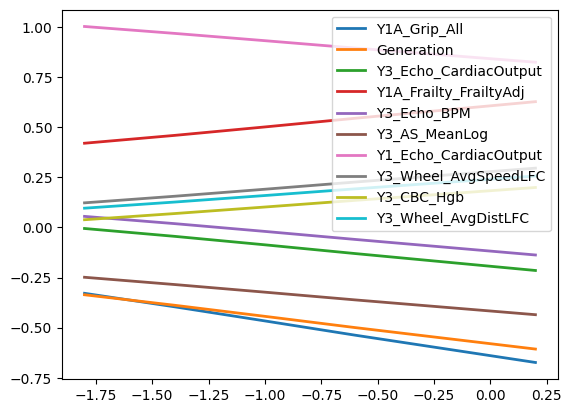

In [59]:
for col_name in difference_lv5_0_ranked.head(10).index.tolist(): 
    plt.plot(
        lv_traversal_values_0, 
        reconstructions_standardized_df_0[col_name], 
        label=col_name, 
        linewidth=2
    )
    plt.legend()

# Doing analysis for LV5 traversal with conditional label 1

In [60]:
unstandardized_data_tensor_1 = reconstructions_standardized_1 * col_std_tensor
unstandardized_data_tensor_1 = unstandardized_data_tensor_1 + col_means_tensor

In [61]:
reconstructions_unstandardized_df_1 = pd.DataFrame(unstandardized_data_tensor_1.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.162016,1159.867798,26.963392,32.046478,25.154743,160.651520,114.156487,110.979385,498.080627,515.083374,...,1.488995,1.216735,-0.157016,145.418884,173.190643,137.247269,0.265522,0.198280,0.245705,2.496260
1,22.189056,1150.734131,27.061081,32.180912,25.425232,161.663071,115.099487,113.606735,498.010040,516.344543,...,1.488893,1.264776,-0.244904,146.979645,173.183899,136.450348,0.265628,0.198916,0.251331,2.538970
2,22.223063,1141.956421,27.150965,32.323471,25.692810,162.633575,116.095230,116.112091,498.132141,517.568787,...,1.491053,1.309409,-0.329276,148.577896,173.194763,135.763412,0.265363,0.199518,0.256510,2.581306
3,22.260525,1133.759033,27.231359,32.465576,25.947142,163.534576,117.093475,118.431442,498.395081,518.722595,...,1.494938,1.350259,-0.407886,150.136841,173.212250,135.188034,0.264830,0.200074,0.261146,2.621855
4,22.298265,1126.314453,27.301102,32.599838,26.179813,164.343369,118.051231,120.516167,498.747894,519.780090,...,1.500023,1.387179,-0.478976,151.591064,173.226593,134.722366,0.264129,0.200575,0.265174,2.659486


In [62]:
reconstructions_standardized_df_1 = pd.DataFrame(reconstructions_standardized_1.cpu(), columns=all_input_features)
reconstructions_standardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.294567,0.861850,0.177055,-0.094951,-0.745401,0.141130,-0.336599,-0.572221,-0.146435,0.282249,...,-0.173080,-0.049454,0.668181,-1.043324,0.126049,0.251588,1.469320,0.075275,-0.449219,-0.234348
1,-1.282739,0.810100,0.197583,-0.079214,-0.725610,0.168965,-0.311277,-0.535313,-0.147821,0.307909,...,-0.173157,-0.018226,0.622347,-1.006334,0.125864,0.234680,1.470678,0.089128,-0.408547,-0.203322
2,-1.267864,0.760367,0.216471,-0.062525,-0.706032,0.195670,-0.284538,-0.500118,-0.145424,0.332816,...,-0.171521,0.010788,0.578346,-0.968455,0.126162,0.220106,1.467277,0.102256,-0.371105,-0.172568
3,-1.251477,0.713922,0.233365,-0.045889,-0.687423,0.220462,-0.257733,-0.467537,-0.140263,0.356290,...,-0.168579,0.037342,0.537350,-0.931508,0.126642,0.207898,1.460445,0.114375,-0.337590,-0.143111
4,-1.234969,0.671742,0.248020,-0.030172,-0.670399,0.242718,-0.232014,-0.438251,-0.133337,0.377806,...,-0.164727,0.061341,0.500277,-0.897042,0.127035,0.198018,1.451446,0.125300,-0.308470,-0.115775


In [63]:
z_min = reconstructions_standardized_df_1.iloc[0]
z_max = reconstructions_standardized_df_1.iloc[-1]
difference_lv5_1 = np.abs(z_max - z_min)
difference_lv5_1_ranked = difference_lv5_1.sort_values(ascending=False)
difference_lv5_1_ranked.head(10)

Y3_Echo_BPM               0.201937
Y3_Echo_CardiacOutput     0.197422
Y3_Wheel_AvgSpeedLFC      0.190339
SurvDays                  0.190108
Y3_Rotarod_Mean           0.179140
Y3_Wheel_AvgDistLFC       0.167904
Y3_CBC_Hgb                0.156363
Y2_CBC_Hgb                0.151822
Y1A_Grip_All              0.146281
Y3A_Frailty_FrailtyAdj    0.140748
dtype: float32

# Doing analysis for LV5 traversal with conditional label 2

In [64]:
unstandardized_data_tensor_2 = reconstructions_standardized_2 * col_std_tensor
unstandardized_data_tensor_2 = unstandardized_data_tensor_2 + col_means_tensor

In [65]:
reconstructions_unstandardized_df_2 = pd.DataFrame(unstandardized_data_tensor_2.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.896654,1114.350464,27.875599,33.940723,27.564594,169.382538,124.211807,123.793488,505.089050,521.608643,...,1.576122,1.305115,-0.638278,160.633118,175.287643,137.982605,0.248550,0.202939,0.265014,2.715565
1,22.855556,1109.976440,27.940863,33.955338,27.716473,169.958923,124.304504,125.239548,504.351562,522.236633,...,1.568115,1.338657,-0.670949,160.387665,175.109711,137.151703,0.250310,0.203517,0.268755,2.731844
2,22.821917,1105.972290,27.998919,33.981834,27.871117,170.508362,124.465034,126.566528,503.851532,522.830811,...,1.562814,1.368318,-0.699570,160.164642,174.949203,136.433487,0.251651,0.204072,0.272024,2.747809
3,22.796021,1102.296509,28.050209,34.021442,28.030472,171.036057,124.700821,127.786850,503.592560,523.398010,...,1.560269,1.394290,-0.724485,159.972092,174.806839,135.826416,0.252566,0.204609,0.274844,2.763708
4,22.776934,1098.943237,28.095060,34.072975,28.194290,171.542084,125.004913,128.904144,503.556610,523.939026,...,1.560295,1.416852,-0.745649,159.796814,174.679810,135.323456,0.253088,0.205133,0.277236,2.779493


In [66]:
reconstructions_standardized_df_2 = pd.DataFrame(reconstructions_standardized_2.cpu(), columns=all_input_features)
reconstructions_standardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.973224,0.603956,0.368742,0.126796,-0.569078,0.381379,-0.066587,-0.392212,-0.008864,0.415009,...,-0.107095,0.007996,0.417199,-0.682745,0.183597,0.267189,1.251586,0.176808,-0.309628,-0.075036
1,-0.991201,0.579173,0.382456,0.128507,-0.557966,0.397239,-0.064097,-0.371899,-0.023341,0.427786,...,-0.113159,0.029800,0.400161,-0.688562,0.178714,0.249561,1.274160,0.189406,-0.282583,-0.063211
2,-1.005915,0.556487,0.394655,0.131609,-0.546651,0.412358,-0.059787,-0.353258,-0.033156,0.439875,...,-0.117173,0.049081,0.385235,-0.693847,0.174310,0.234323,1.291368,0.201503,-0.258945,-0.051613
3,-1.017243,0.535660,0.405433,0.136246,-0.534991,0.426878,-0.053455,-0.336115,-0.038239,0.451414,...,-0.119100,0.065964,0.372242,-0.698411,0.170403,0.221442,1.303100,0.213212,-0.238558,-0.040063
4,-1.025591,0.516661,0.414858,0.142278,-0.523005,0.440802,-0.045290,-0.320419,-0.038945,0.462421,...,-0.119081,0.080630,0.361205,-0.702565,0.166916,0.210771,1.309797,0.224623,-0.221266,-0.028597


In [67]:
z_min = reconstructions_standardized_df_2.iloc[0]
z_max = reconstructions_standardized_df_2.iloc[-1]
difference_lv5_2 = np.abs(z_max - z_min)
difference_lv5_2_ranked = difference_lv5_2.sort_values(ascending=False)
difference_lv5_2_ranked.head(10)

Y2_CBC_Hgb                0.091270
Y3A_Frailty_FrailtyAdj    0.088362
SurvDays                  0.087295
Y1_Echo_CardiacOutput     0.078936
Y2_Wheel_AvgDistLFC       0.072633
Y3_Glu.F_Glucose          0.071793
Y3_Echo_BPM               0.069656
Y3_Rotarod_Mean           0.067968
Y3_Wheel_AvgSpeedLFC      0.067373
Y3_Echo_CardiacOutput     0.061769
dtype: float32

# Doing analysis for LV5 traversal with conditional label 3

In [68]:
unstandardized_data_tensor_3 = reconstructions_standardized_3 * col_std_tensor
unstandardized_data_tensor_3 = unstandardized_data_tensor_3 + col_means_tensor

In [69]:
reconstructions_unstandardized_df_3 = pd.DataFrame(unstandardized_data_tensor_3.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.964867,1034.538086,28.922407,37.932323,33.774349,185.427124,145.047302,149.843857,529.136353,534.430664,...,1.831272,1.430507,-1.180263,175.015671,177.757660,135.939789,0.206493,0.215341,0.298833,3.215824
1,23.875299,1036.829834,28.925751,37.834526,33.768456,185.380493,144.345520,149.475845,528.375000,534.172791,...,1.822686,1.434388,-1.140232,172.936859,177.442535,135.483109,0.208754,0.215655,0.298738,3.199283
2,23.785185,1039.255249,28.927500,37.735077,33.759674,185.320847,143.632462,149.070175,527.625244,533.897766,...,1.814230,1.437590,-1.098733,170.826050,177.125198,135.037933,0.211004,0.215963,0.298552,3.182156
3,23.696417,1041.721191,28.928249,37.637978,33.752163,185.259338,142.932327,148.651413,526.913940,533.619263,...,1.806201,1.440210,-1.056758,168.722839,176.811371,134.608353,0.213185,0.216269,0.298304,3.165065
4,23.610680,1044.145264,28.928530,37.546707,33.749546,185.205780,142.266357,148.241333,526.264404,533.349609,...,1.798855,1.442340,-1.015196,166.662430,176.506134,134.197952,0.215246,0.216574,0.298020,3.148558


In [70]:
reconstructions_standardized_df_3 = pd.DataFrame(reconstructions_standardized_3.cpu(), columns=all_input_features)
reconstructions_standardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.505970,0.151752,0.588713,0.594068,-0.114725,0.822873,0.492902,-0.026265,0.463171,0.675879,...,0.086142,0.089506,0.134550,-0.341876,0.251383,0.223848,0.712034,0.447114,-0.065128,0.288371
1,-0.545148,0.164737,0.589416,0.582619,-0.115156,0.821589,0.474057,-0.031435,0.448226,0.670633,...,0.079639,0.092029,0.155426,-0.391144,0.242735,0.214159,0.741048,0.453970,-0.065816,0.276355
2,-0.584566,0.178479,0.589783,0.570977,-0.115799,0.819948,0.454909,-0.037133,0.433509,0.665036,...,0.073236,0.094110,0.177069,-0.441171,0.234026,0.204714,0.769915,0.460681,-0.067161,0.263913
3,-0.623394,0.192451,0.589940,0.559610,-0.116348,0.818256,0.436109,-0.043016,0.419546,0.659371,...,0.067155,0.095814,0.198959,-0.491017,0.225413,0.195599,0.797895,0.467332,-0.068953,0.251498
4,-0.660897,0.206185,0.589999,0.548926,-0.116539,0.816782,0.418226,-0.048777,0.406796,0.653884,...,0.061591,0.097198,0.220634,-0.539849,0.217037,0.186892,0.824335,0.473997,-0.071006,0.239506


In [71]:
z_min = reconstructions_standardized_df_3.iloc[0]
z_max = reconstructions_standardized_df_3.iloc[-1]
difference_lv5_3 = np.abs(z_max - z_min)
difference_lv5_3_ranked = difference_lv5_3.sort_values(ascending=False)
difference_lv5_3_ranked.head(10)

Y1A_Grip_All              0.197973
Generation                0.154927
Y1A_Frailty_FrailtyAdj    0.112301
Y3_Echo_CardiacOutput     0.107046
Y3_AS_MeanLog             0.105832
Y1_Echo_CardiacOutput     0.100573
Y3_Echo_BPM               0.098237
Y3_Wheel_AvgSpeedLFC      0.092103
Y3_CBC_Hgb                0.087018
Y3_Wheel_AvgDistLFC       0.086084
dtype: float32

# Doing analysis for LV5 traversal with conditional label 4

In [72]:
unstandardized_data_tensor_4 = reconstructions_standardized_4 * col_std_tensor
unstandardized_data_tensor_4 = unstandardized_data_tensor_4 + col_means_tensor

In [73]:
reconstructions_unstandardized_df_4 = pd.DataFrame(unstandardized_data_tensor_4.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.955399,1024.526123,28.976721,38.214298,35.341549,188.702728,145.423538,154.631683,530.099121,533.700256,...,1.816204,1.424805,-1.133099,169.303604,177.269638,131.673462,0.202590,0.217590,0.307924,3.226410
1,23.871881,1027.217285,28.975689,38.111252,35.324440,188.636383,144.689713,154.114822,529.416565,533.338684,...,1.808463,1.424775,-1.090050,167.218384,176.957596,131.281555,0.204615,0.217820,0.307408,3.206783
2,23.793957,1029.713867,28.975204,38.018917,35.317268,188.593185,144.020493,153.646713,528.819824,533.006165,...,1.801668,1.424559,-1.049141,165.237885,176.662613,130.909836,0.206456,0.218055,0.306921,3.188639
3,23.700130,1032.673584,28.975830,37.915104,35.325745,188.579041,143.245102,153.115433,528.174988,532.617615,...,1.794269,1.424060,-0.998682,162.790176,176.300049,130.448624,0.208584,0.218377,0.306336,3.167183
4,23.618698,1035.165649,28.978214,37.834869,35.356190,188.618973,142.613113,152.701630,527.710938,532.297729,...,1.788866,1.423397,-0.953445,160.583923,175.975388,130.028336,0.210318,0.218709,0.305843,3.149126


In [74]:
reconstructions_standardized_df_4 = pd.DataFrame(reconstructions_standardized_4.cpu(), columns=all_input_features)
reconstructions_standardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.510111,0.095026,0.600126,0.627077,-0.000056,0.913007,0.503005,0.040993,0.482069,0.661019,...,0.074730,0.085799,0.159146,-0.477253,0.237990,0.133331,0.661973,0.496124,0.000597,0.296062
1,-0.546643,0.110274,0.599909,0.615014,-0.001308,0.911180,0.483300,0.033732,0.468671,0.653661,...,0.068868,0.085780,0.181597,-0.526673,0.229426,0.125016,0.687948,0.501153,-0.003133,0.281803
2,-0.580728,0.124419,0.599807,0.604205,-0.001833,0.909992,0.465329,0.027156,0.456958,0.646897,...,0.063721,0.085640,0.202931,-0.573611,0.221331,0.117130,0.711561,0.506275,-0.006657,0.268623
3,-0.621770,0.141189,0.599939,0.592052,-0.001213,0.909603,0.444508,0.019693,0.444300,0.638992,...,0.058118,0.085315,0.229246,-0.631622,0.211381,0.107345,0.738865,0.513287,-0.010884,0.253036
4,-0.657389,0.155308,0.600440,0.582660,0.001015,0.910702,0.427537,0.013880,0.435191,0.632483,...,0.054026,0.084884,0.252837,-0.683910,0.202471,0.098427,0.761107,0.520515,-0.014453,0.239919


In [75]:
z_min = reconstructions_standardized_df_4.iloc[0]
z_max = reconstructions_standardized_df_4.iloc[-1]
difference_lv5_4 = np.abs(z_max - z_min)
difference_lv5_4_ranked = difference_lv5_4.sort_values(ascending=False)
difference_lv5_4_ranked.head(10)

Y1A_Grip_All              0.206658
Generation                0.147278
Y3_Echo_CardiacOutput     0.115206
Y3_AS_MeanLog             0.110284
Y3_Echo_BPM               0.109468
Y3_Wheel_AvgSpeedLFC      0.102692
Y1A_Frailty_FrailtyAdj    0.099134
Y3_CBC_Hgb                0.096850
Y1_Echo_CardiacOutput     0.095445
Y3_Wheel_AvgDistLFC       0.093691
dtype: float32

In [76]:
Counter(difference_lv5_4_ranked.head(10).index.to_list() + difference_lv5_3_ranked.head(10).index.to_list() + difference_lv5_2_ranked.head(10).index.to_list() + difference_lv5_1_ranked.head(10).index.to_list() + difference_lv5_0_ranked.head(10).index.to_list())

Counter({'Y3_Echo_CardiacOutput': 5,
         'Y3_Echo_BPM': 5,
         'Y3_Wheel_AvgSpeedLFC': 5,
         'Y1A_Grip_All': 4,
         'Y3_CBC_Hgb': 4,
         'Y1_Echo_CardiacOutput': 4,
         'Y3_Wheel_AvgDistLFC': 4,
         'Generation': 3,
         'Y3_AS_MeanLog': 3,
         'Y1A_Frailty_FrailtyAdj': 3,
         'Y2_CBC_Hgb': 2,
         'Y3A_Frailty_FrailtyAdj': 2,
         'SurvDays': 2,
         'Y3_Rotarod_Mean': 2,
         'Y2_Wheel_AvgDistLFC': 1,
         'Y3_Glu.F_Glucose': 1})

## Calculates the distances and combines timepoint variables

In [88]:
def calc_differences(reconstructions_standardized):
    cum_difference = np.abs(reconstructions_standardized.iloc[-1, [0, 1]] - reconstructions_standardized.iloc[0, [0, 1]])
    cum_difference = pd.concat([cum_difference, np.abs(reconstructions_standardized.iloc[-1, [-1]] - reconstructions_standardized.iloc[0, [-1]])])
    max_data = reconstructions_standardized.iloc[-1, 2:-1]
    min_data = reconstructions_standardized.iloc[0, 2:-1]
    feature_names = max_data.index.tolist()
    max_data_np = max_data.to_numpy()
    min_data_np = min_data.to_numpy()
    for feature in range(int(len(max_data) / 3)): 
        feature_name = feature_names[feature*3]
        feature_name = feature_name.split('_', 1)[1]
        max_vector = max_data_np[feature:feature+3]
        min_vector = min_data_np[feature:feature+3]
        diff = np.abs(max_vector-min_vector)
        #dist = np.linalg.norm(diff)
        dist = np.mean(diff, axis=0)
        cum_difference = pd.concat([cum_difference, pd.Series(data=dist, index=[feature_name])])
    return cum_difference

In [89]:
cum_difference_0 = calc_differences(reconstructions_standardized_df_0)
cum_difference_0.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_0_LV3.csv')
cum_difference_0.sort_values(ascending=False)

Generation            0.270678
Grip_All              0.152464
Wheel_AvgDistLFC      0.146804
Wheel_AvgSpeedLFC     0.143167
AS_MeanLog            0.124122
SurvDays              0.118603
CBC_Hgb               0.113353
Diet_num              0.107826
Frailty_FrailtyAdj    0.094393
Echo_CardiacOutput    0.084150
Rotarod_Mean          0.080145
Echo_BPM              0.073052
Glu.F_Glucose         0.054096
BW_BW                 0.046804
dtype: float32

In [90]:
cum_difference_1 = calc_differences(reconstructions_standardized_df_1)
cum_difference_1.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_1_LV3.csv')
cum_difference_1.sort_values(ascending=False)

SurvDays              0.190108
Diet_num              0.118574
Echo_CardiacOutput    0.113381
Wheel_AvgSpeedLFC     0.109780
Wheel_AvgDistLFC      0.106572
Grip_All              0.105068
AS_MeanLog            0.103531
Frailty_FrailtyAdj    0.099212
Echo_BPM              0.093725
CBC_Hgb               0.083884
Rotarod_Mean          0.080875
Glu.F_Glucose         0.080456
BW_BW                 0.070248
Generation            0.059598
dtype: float32

In [91]:
cum_difference_2 = calc_differences(reconstructions_standardized_df_2)
cum_difference_2.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_2_LV3.csv')
cum_difference_2.sort_values(ascending=False)

SurvDays              0.087295
Wheel_AvgSpeedLFC     0.065335
Wheel_AvgDistLFC      0.062497
Grip_All              0.059868
Generation            0.052367
Echo_CardiacOutput    0.050838
Rotarod_Mean          0.049762
AS_MeanLog            0.049050
Diet_num              0.046440
Echo_BPM              0.042265
CBC_Hgb               0.041057
Glu.F_Glucose         0.040326
Frailty_FrailtyAdj    0.037032
BW_BW                 0.035891
dtype: float32

In [92]:
cum_difference_3 = calc_differences(reconstructions_standardized_df_3)
cum_difference_3.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_3_LV3.csv')
cum_difference_3.sort_values(ascending=False)

Generation            0.154927
Grip_All              0.078243
Wheel_AvgDistLFC      0.075307
Wheel_AvgSpeedLFC     0.073602
AS_MeanLog            0.058869
SurvDays              0.054433
CBC_Hgb               0.051188
Diet_num              0.048865
Frailty_FrailtyAdj    0.045523
Echo_CardiacOutput    0.034426
Rotarod_Mean          0.033627
Echo_BPM              0.027527
Glu.F_Glucose         0.017683
BW_BW                 0.016081
dtype: float32

In [93]:
cum_difference_4 = calc_differences(reconstructions_standardized_df_4)
cum_difference_4.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_4_LV3.csv')
cum_difference_4.sort_values(ascending=False)

Generation            0.147278
Grip_All              0.078120
Wheel_AvgSpeedLFC     0.077816
Wheel_AvgDistLFC      0.076207
AS_MeanLog            0.061627
SurvDays              0.060282
Diet_num              0.056142
CBC_Hgb               0.049820
Frailty_FrailtyAdj    0.046566
Echo_CardiacOutput    0.034962
Rotarod_Mean          0.034176
Echo_BPM              0.026281
Glu.F_Glucose         0.015931
BW_BW                 0.015267
dtype: float32